# Exploratory Data Analysis

We will be exploring the CyberBullying Detection Dataset sourced from Kaggle in order to understand the dataset better. We want to know:
- How many samples there are
- What's the label distribution
- What's the average / max text length
- Are there nulls
- What do positive examples look like

## Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Makes plots render inline in the notebook
%matplotlib inline

# Nicer default plot style
sns.set_theme(style="whitegrid")

print("Imports OK")

Imports OK


## Load Data

In [20]:
df = pd.read_csv("../data/raw/hateXplain.csv")

print(f"Shape: {df.shape}") # Shape
print(20 * "-")

df.info() # Basic info: col names, data types
print(20 * "-")

df.isnull().sum() # Null check
df.head(10) # Peek entries


Shape: (60444, 5)
--------------------
<class 'pandas.DataFrame'>
RangeIndex: 60444 entries, 0 to 60443
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   post_id       60444 non-null  str  
 1   annotator_id  60444 non-null  int64
 2   label         60444 non-null  str  
 3   target        39252 non-null  str  
 4   post_tokens   60444 non-null  str  
dtypes: int64(1), str(4)
memory usage: 2.3 MB
--------------------


,post_id,annotator_id,label,target,post_tokens
0,1179055004553900032_twitter,1,normal,NaN,i dont think im getting my baby them white 9 h...
1,1179055004553900032_twitter,2,normal,NaN,i dont think im getting my baby them white 9 h...
2,1179055004553900032_twitter,3,normal,NaN,i dont think im getting my baby them white 9 h...
3,1179063826874032128_twitter,1,normal,NaN,we cannot continue calling ourselves feminists...
4,1179063826874032128_twitter,2,normal,NaN,we cannot continue calling ourselves feminists...
5,1179063826874032128_twitter,3,normal,NaN,we cannot continue calling ourselves feminists...
6,1178793830532956161_twitter,4,normal,African,nawt yall niggers ignoring me
7,1178793830532956161_twitter,2,normal,NaN,nawt yall niggers ignoring me
8,1178793830532956161_twitter,3,hatespeech,African,nawt yall niggers ignoring me
9,1179088797964763136_twitter,1,hatespeech,Asian,<user> i am bit confused coz chinese ppl can n...


## Unique Posts

Worth nothing that Annotator 4 has annotated the most posts (5730), while many from the 253 unique annotators annotate only a handful of posts. This could introduce a bias if Annotator 4 has a different interpretation of the posts than others.

In [23]:
unique_posts = df['post_id'].nunique()
total_rows = len(df)

print(f"Total rows:     {total_rows}")
print(f"Unique posts:   {unique_posts}")
print(f"Avg annotators per post: {total_rows / unique_posts:.2f}")
print(20 * "-")

print(df['annotator_id'].value_counts())

Total rows:     60444
Unique posts:   20148
Avg annotators per post: 3.00
--------------------
annotator_id
4      5730
9      2075
223    1978
203    1918
209    1769
       ... 
174       3
188       3
192       3
190       2
138       1
Name: count, Length: 253, dtype: int64


## Label Counts

Distribution of labels. How many are normal, hatespeech, offensive.

In [24]:
label_counts = df['label'].value_counts()
label_pcts = df['label'].value_counts(normalize=True) * 100

print(label_counts)
print()
print(label_pcts.round(2))

label
normal        24449
hatespeech    18070
offensive     17925
Name: count, dtype: int64

label
normal        40.45
hatespeech    29.90
offensive     29.66
Name: proportion, dtype: float64


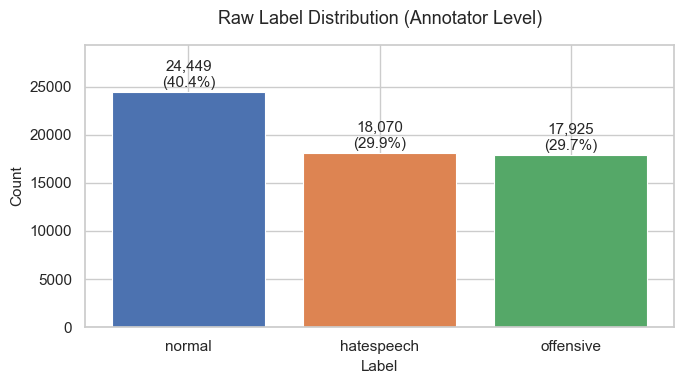

In [26]:
fig, ax = plt.subplots(figsize=(7, 4))

colors = ['#4C72B0', '#DD8452', '#55A868']
bars = ax.bar(label_counts.index, label_counts.values, color=colors, edgecolor='white', linewidth=0.8)

# Add count + percentage labels on each bar
for bar, count, pct in zip(bars, label_counts.values, label_pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{count:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=11)

ax.set_title('Raw Label Distribution (Annotator Level)', fontsize=13, pad=15)
ax.set_xlabel('Label', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_ylim(0, label_counts.max() * 1.2)

plt.tight_layout()
plt.savefig('../assets/label_distribution_raw.png', dpi=150, bbox_inches='tight')
plt.show()

## Annotator Agreement
How often the annotators agree with each other. Very notably, it is close to a 50/50. My original hypothesis was that annotators had difficulty differentiating 'offensive' and 'hatespeech'. Further exploration showed a different story.

In truth, about 20% of disagreements come from 'normal' vs 'offensive' and about 20% more come from 'offensive' vs 'hatespeech'.

There is also a small percentage (4.6%, 919) of posts where all annotators label differently than each other. These will be flagged as 'undecided' after majority vote aggregation.

Moving forward, hard label are less effective. Instead, confidence scores on each label would be more meaningful.

In [27]:
# For each post, get all labels assigned to it
agreement = df.groupby('post_id')['label'].agg(list).reset_index()
agreement.columns = ['post_id', 'labels']

# Check if all annotators agreed
agreement['unanimous'] = agreement['labels'].apply(lambda x: len(set(x)) == 1)

unanimous_count = agreement['unanimous'].sum()
total_posts = len(agreement)
disagreement_count = total_posts - unanimous_count

print(f"Total posts:           {total_posts:,}")
print(f"Unanimous agreement:   {unanimous_count:,} ({unanimous_count/total_posts*100:.1f}%)")
print(f"Disagreement:          {disagreement_count:,} ({disagreement_count/total_posts*100:.1f}%)")

Total posts:           20,148
Unanimous agreement:   9,845 (48.9%)
Disagreement:          10,303 (51.1%)


In [28]:
def get_disagreement_type(labels):
    unique = set(labels)
    if len(unique) == 1:
        return 'unanimous'
    elif unique == {'offensive', 'hatespeech'}:
        return 'offensive vs hatespeech'
    elif unique == {'normal', 'offensive'}:
        return 'normal vs offensive'
    elif unique == {'normal', 'hatespeech'}:
        return 'normal vs hatespeech'
    else:
        return 'all three differ'

disagreement_df = df.groupby('post_id')['label'].agg(list).reset_index()
disagreement_df.columns = ['post_id', 'labels']
disagreement_df['disagreement_type'] = disagreement_df['labels'].apply(get_disagreement_type)

type_counts = disagreement_df['disagreement_type'].value_counts()
type_pcts = disagreement_df['disagreement_type'].value_counts(normalize=True) * 100

print(type_counts)
print()
print(type_pcts.round(2))

disagreement_type
unanimous                  9845
normal vs offensive        4088
offensive vs hatespeech    3916
normal vs hatespeech       1380
all three differ            919
Name: count, dtype: int64

disagreement_type
unanimous                  48.86
normal vs offensive        20.29
offensive vs hatespeech    19.44
normal vs hatespeech        6.85
all three differ            4.56
Name: proportion, dtype: float64


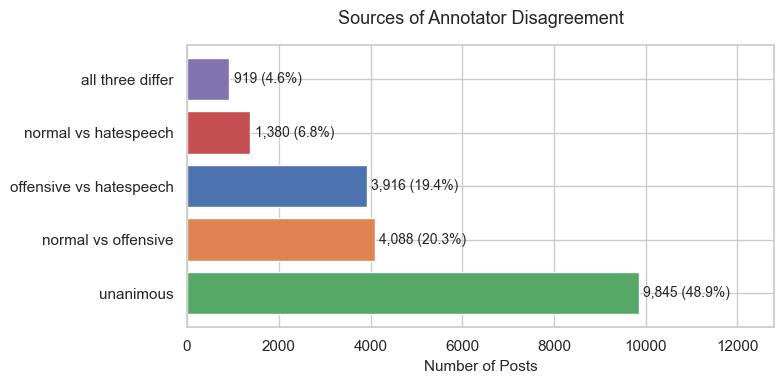

In [29]:
fig, ax = plt.subplots(figsize=(8, 4))

colors = ['#55A868', '#DD8452', '#4C72B0', '#C44E52', '#8172B2']
bars = ax.barh(type_counts.index, type_counts.values, color=colors, edgecolor='white')

for bar, count, pct in zip(bars, type_counts.values, type_pcts.values):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{count:,} ({pct:.1f}%)',
            va='center', fontsize=10)

ax.set_title('Sources of Annotator Disagreement', fontsize=13, pad=15)
ax.set_xlabel('Number of Posts', fontsize=11)
ax.set_xlim(0, type_counts.max() * 1.3)

plt.tight_layout()
plt.savefig('../assets/disagreement_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

## Majority Vote Aggregation

In [30]:
from collections import Counter

def majority_vote(labels):
    count = Counter(labels)
    top_two = count.most_common(2)
    # True 3-way tie: all three annotators picked different labels
    if len(top_two) > 1 and top_two[0][1] == top_two[1][1]:
        return 'undecided'
    return top_two[0][0]

# Aggregate labels
post_labels = df.groupby('post_id')['label'].agg(list).reset_index()
post_labels.columns = ['post_id', 'all_labels']
post_labels['final_label'] = post_labels['all_labels'].apply(majority_vote)

print(post_labels['final_label'].value_counts())
print(f"\nUndecided posts: {(post_labels['final_label'] == 'undecided').sum()}")

final_label
normal        7814
hatespeech    5935
offensive     5480
undecided      919
Name: count, dtype: int64

Undecided posts: 919


### Aggregate Other Columns

In [31]:
# post_tokens is the same for all annotators of a post — just take the first
post_tokens = df.groupby('post_id')['post_tokens'].first().reset_index()

# target: collect all unique non-null targets across annotators
def aggregate_targets(targets):
    all_targets = []
    for t in targets:
        if pd.notna(t):
            # targets are comma-separated strings like "African, Jewish"
            all_targets.extend([x.strip() for x in t.split(',')])
    unique_targets = list(set(all_targets))
    return unique_targets if unique_targets else None

post_targets = df.groupby('post_id')['target'].agg(list).reset_index()
post_targets['target_groups'] = post_targets['target'].apply(aggregate_targets)
post_targets = post_targets[['post_id', 'target_groups']]

# Merge everything into one clean post-level dataframe
posts = post_labels[['post_id', 'final_label']].merge(post_tokens, on='post_id').merge(post_targets, on='post_id')

print(f"Shape: {posts.shape}")
print(f"\nColumns: {posts.columns.tolist()}")
posts.head(3)

Shape: (20148, 4)

Columns: ['post_id', 'final_label', 'post_tokens', 'target_groups']


,post_id,final_label,post_tokens,target_groups
0,10001291_gab,hatespeech,jews are responsible for destroying my towns c...,[Jewish]
1,10002346_gab,normal,leftist mind control fails i think this overst...,"[Men, Women, Other]"
2,10007406_gab,undecided,the scientific findings that advocates and the...,[Homosexual]


In [32]:
undecided = posts[posts['final_label'] == 'undecided']
decided = posts[posts['final_label'] != 'undecided']

print(f"Decided posts:   {len(decided):,}")
print(f"Undecided posts: {len(undecided):,}")
print(f"\nUndecided breakdown:")
print(undecided.shape)

Decided posts:   19,229
Undecided posts: 919

Undecided breakdown:
(919, 4)


Reading the undecided posts, they can be clearly labelled as offensive at a minimum. I came to a hypothesis that since there are 3 labels, 'normal', 'offensive', and 'hatespeech', a 3-way tie means that 2 annotators chose a label describing a post as harmful while 1 has labelled them normal. If we aggregate in this manner, and assign the undecided posts as 'offensive', we do not drop any data in our dataset.

Another approach is to keep these, and use these ambiguous posts as test cases against the trained model.

In [35]:
# Read a few undecided examples
for _, row in undecided.head(5).iterrows():
    print(f"Post:   {row['post_tokens']}")
    print(f"Label:  {row['final_label']}")
    print(f"Target: {row['target_groups']}")
    print("-" * 60)

Post:   the scientific findings that advocates and the pro gay media cite tend to come from decidedly unrepresentative samples that have been collected from places like bulletin boards at gay parenting support groups where everyone has an interest in proving that gay parenting is a success austin ruse
Label:  undecided
Target: ['Homosexual']
------------------------------------------------------------
Post:   right definitely not going back to the fag hag thing it was fun for a bit in my <number> but outrageously gay people are just too high strung for me it back to that reason i can not be a lesbian
Label:  undecided
Target: ['Homosexual']
------------------------------------------------------------
Post:   às vezes eu esqueço que meu nome tem origem sandnigger
Label:  undecided
Target: ['Arab']
------------------------------------------------------------
Post:   evo1014 days ago edited here in san francisco the roma women sit their children on the sidewalk with signs begging for cash

In [34]:
def get_vote_split(labels):
    count = Counter(labels)
    # Sort for consistent display e.g. "hatespeech:1, normal:1, offensive:1"
    return ', '.join([f"{k}:{v}" for k, v in sorted(count.items())])

# Get the undecided posts with their original labels
undecided_with_labels = post_labels[post_labels['final_label'] == 'undecided'].copy()
undecided_with_labels['vote_split'] = undecided_with_labels['all_labels'].apply(get_vote_split)

print(undecided_with_labels['vote_split'].value_counts())

vote_split
hatespeech:1, normal:1, offensive:1    919
Name: count, dtype: int64


## Data Cleaning

In [36]:
# Final clean dataset for training
clean_posts = posts[posts['final_label'] != 'undecided'].copy()
clean_posts = clean_posts.rename(columns={'final_label': 'label'})

# Ambiguous set — reserved for post-training analysis
ambiguous_posts = posts[posts['final_label'] == 'undecided'].copy()

print(f"Clean posts (for training): {len(clean_posts):,}")
print(f"Ambiguous posts (for analysis): {len(ambiguous_posts):,}")
print(f"\nClean label distribution:")
print(clean_posts['label'].value_counts())
print()
print(clean_posts['label'].value_counts(normalize=True).mul(100).round(2))

Clean posts (for training): 19,229
Ambiguous posts (for analysis): 919

Clean label distribution:
label
normal        7814
hatespeech    5935
offensive     5480
Name: count, dtype: int64

label
normal        40.64
hatespeech    30.86
offensive     28.50
Name: proportion, dtype: float64


## Text Analysis
- Max post length: 165 words. Zero posts exceed 512 tokens — truncation 
  is not a concern. Max token length of 128 will cover 99.97% of posts.
- Mean word count is nearly identical across all three classes (~22-25 words),
  confirming that length carries no discriminative signal. The model must 
  learn from lexical and semantic content, not post length.

In [39]:
for _, row in clean_posts.head(5).iterrows():
    print(f"Label:  {row['label']}")
    print(f"Tokens: {row['post_tokens']}")
    print("-" * 60)

# Look at one entry in full
sample = clean_posts['post_tokens'].iloc[0]
print(type(sample))
print(repr(sample))

Label:  hatespeech
Tokens: jews are responsible for destroying my towns culture and turning leeds into a ghetto hell of dollarstan full of dollarstanis please killalljewz
------------------------------------------------------------
Label:  normal
Tokens: leftist mind control fails i think this overstates it men prefer women who are real people and prefer tall thin young bodies if asked in abstraction the two are not the same question
------------------------------------------------------------
Label:  hatespeech
Tokens: it why they behave like animals no matter where you put them they will destroy anything of value black people want to claim we are the racists but then why do they move out of the ghetto once they have success even they do not want to live around their own kind
------------------------------------------------------------
Label:  offensive
Tokens: why are people so offended by the word paki surely the word fucking that comes before is more offensive
---------------------

In [40]:
# Word count per post
clean_posts['word_count'] = clean_posts['post_tokens'].apply(lambda x: len(x.split()))

print("Word count statistics:")
print(clean_posts['word_count'].describe().round(2))
print(f"\nPosts exceeding 512 words: {(clean_posts['word_count'] > 512).sum()}")
print(f"Posts exceeding 128 words: {(clean_posts['word_count'] > 128).sum()}")
print(f"Posts exceeding 64 words:  {(clean_posts['word_count'] > 64).sum()}")

Word count statistics:
count    19229.00
mean        23.43
std         13.79
min          2.00
25%         12.00
50%         21.00
75%         34.00
max        165.00
Name: word_count, dtype: float64

Posts exceeding 512 words: 0
Posts exceeding 128 words: 1
Posts exceeding 64 words:  5


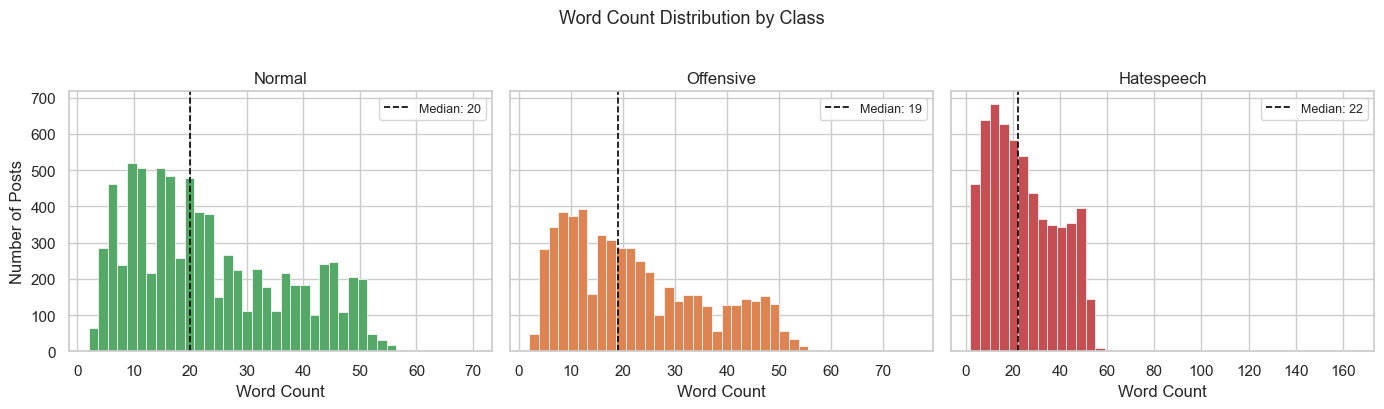

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

colors = {'normal': '#55A868', 'offensive': '#DD8452', 'hatespeech': '#C44E52'}

for ax, label in zip(axes, ['normal', 'offensive', 'hatespeech']):
    subset = clean_posts[clean_posts['label'] == label]['word_count']
    ax.hist(subset, bins=40, color=colors[label], edgecolor='white', linewidth=0.5)
    ax.axvline(subset.median(), color='black', linestyle='--', linewidth=1.2, label=f'Median: {subset.median():.0f}')
    ax.set_title(f'{label.capitalize()}', fontsize=12)
    ax.set_xlabel('Word Count')
    ax.legend(fontsize=9)

axes[0].set_ylabel('Number of Posts')
fig.suptitle('Word Count Distribution by Class', fontsize=13, y=1.02)

plt.tight_layout()
plt.savefig('../assets/length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [42]:
print("Average word count by label:")
print(clean_posts.groupby('label')['word_count'].agg(['mean', 'median', 'max']).round(2))

Average word count by label:
             mean  median  max
label                         
hatespeech  24.57    22.0  165
normal      23.32    20.0   70
offensive   22.36    19.0   76


## Word Analysis

In [43]:
from collections import Counter

# Common stopwords to exclude — they appear in all classes equally
stopwords = {
    'i', 'me', 'my', 'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on',
    'at', 'to', 'for', 'of', 'with', 'is', 'it', 'this', 'that', 'was',
    'are', 'be', 'as', 'at', 'by', 'he', 'she', 'they', 'we', 'you',
    'his', 'her', 'their', 'our', 'your', 'its', 'have', 'had', 'has',
    'do', 'did', 'does', 'will', 'would', 'could', 'should', 'not', 'no',
    'so', 'if', 'all', 'been', 'from', 'what', 'there', 'about', 'up',
    'out', 'who', 'get', 'just', 'one', 'can', 'more', 'also', 'into',
    'than', 'then', 'them', 'these', 'some', 'dont', 'im', 'like'
}

def get_top_words(df, label, n=30):
    text = ' '.join(df[df['label'] == label]['post_tokens'].tolist())
    words = [w.lower() for w in text.split() if w.lower() not in stopwords and len(w) > 2]
    return Counter(words).most_common(n)

for label in ['normal', 'offensive', 'hatespeech']:
    print(f"\n--- {label.upper()} --- top 15 words")
    top = get_top_words(clean_posts, label, n=15)
    for word, count in top:
        print(f"  {word:<20} {count:,}")


--- NORMAL --- top 15 words
  <user>               4,768
  white                1,907
  <number>             1,326
  people               830
  women                738
  raped                449
  muslim               447
  black                429
  when                 426
  hate                 417
  violence             409
  how                  402
  being                385
  gay                  372
  immigrants           367

--- OFFENSIVE --- top 15 words
  <user>               1,573
  white                774
  <number>             721
  retarded             631
  bitch                479
  ghetto               453
  people               405
  women                405
  jews                 323
  how                  288
  fucking              287
  when                 274
  why                  264
  shit                 258
  gay                  256

--- HATESPEECH --- top 15 words
  nigger               1,716
  white                988
  kike                 913
  <nu

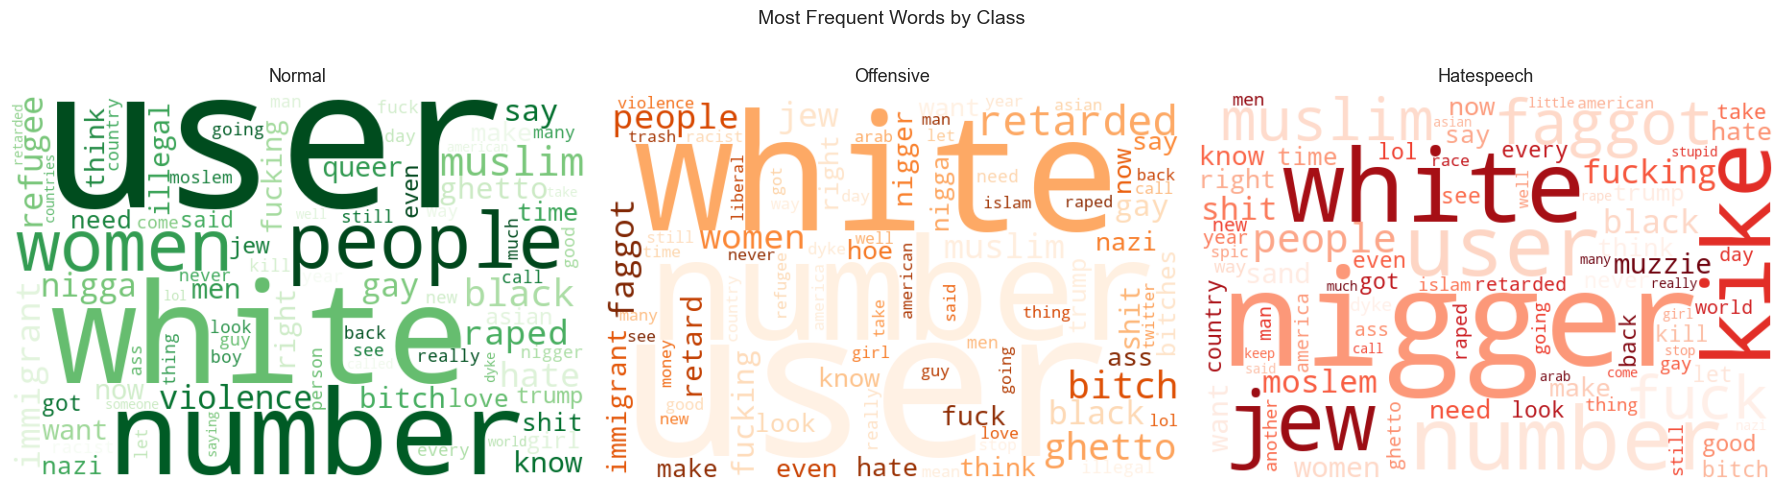

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors_map = {
    'normal': 'Greens',
    'offensive': 'Oranges', 
    'hatespeech': 'Reds'
}

for ax, label in zip(axes, ['normal', 'offensive', 'hatespeech']):
    text = ' '.join(clean_posts[clean_posts['label'] == label]['post_tokens'].tolist())
    
    # Remove stopwords
    text = ' '.join([w for w in text.lower().split() 
                     if w not in stopwords and len(w) > 2])
    
    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap=colors_map[label],
        max_words=80,
        collocations=False   # avoids repeating word pairs
    ).generate(text)
    
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{label.capitalize()}', fontsize=13, pad=10)

fig.suptitle('Most Frequent Words by Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../assets/wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

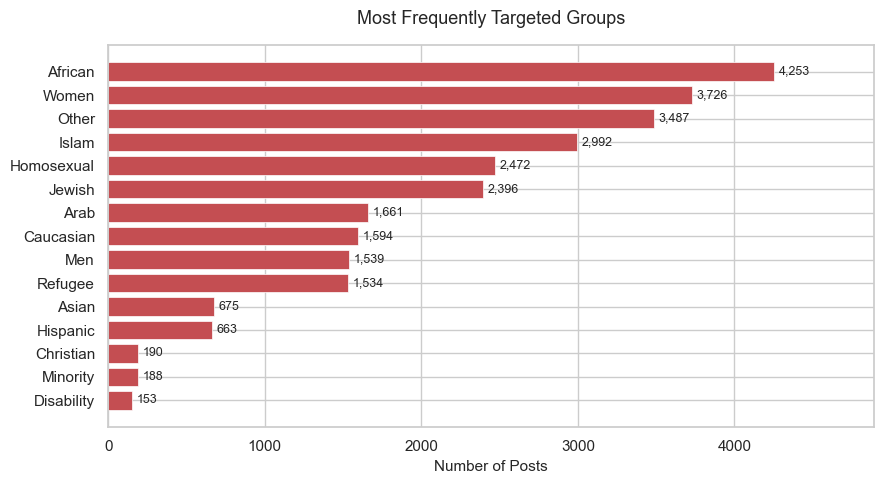

In [45]:
# Explode the target_groups list into individual rows
target_exploded = clean_posts.explode('target_groups').dropna(subset=['target_groups'])
target_exploded['target_groups'] = target_exploded['target_groups'].str.strip()

target_counts = target_exploded['target_groups'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(target_counts.index[::-1], target_counts.values[::-1], 
               color='#C44E52', edgecolor='white', linewidth=0.5)

for bar, count in zip(bars, target_counts.values[::-1]):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontsize=9)

ax.set_title('Most Frequently Targeted Groups', fontsize=13, pad=15)
ax.set_xlabel('Number of Posts', fontsize=11)
ax.set_xlim(0, target_counts.max() * 1.15)

plt.tight_layout()
plt.savefig('../assets/target_groups.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
for token in ['<user>', '<number>']:
    print(f"\n--- '{token}' presence by class ---")
    
    contains = clean_posts['post_tokens'].str.contains(token, regex=False)
    
    for label in ['normal', 'offensive', 'hatespeech']:
        subset = clean_posts[clean_posts['label'] == label]
        count = subset['post_tokens'].str.contains(token, regex=False).sum()
        pct = count / len(subset) * 100
        print(f"  {label:<12} {count:>5,} posts  ({pct:.1f}%)")
    
    total = contains.sum()
    print(f"  {'total':<12} {total:>5,} posts  ({total/len(clean_posts)*100:.1f}%)")


--- '<user>' presence by class ---
  normal       2,915 posts  (37.3%)
  offensive    1,249 posts  (22.8%)
  hatespeech     645 posts  (10.9%)
  total        4,809 posts  (25.0%)

--- '<number>' presence by class ---
  normal         835 posts  (10.7%)
  offensive      516 posts  (9.4%)
  hatespeech     576 posts  (9.7%)
  total        1,927 posts  (10.0%)


## Special Token Analysis

The dataset contains 20 unique special tokens across three categories:

**Privacy placeholders** (\<user\>, \<number\>, \<date\>, etc.): Appear most 
frequently in *normal* posts (45.3%) vs hatespeech (20.6%), suggesting 
hate speech is more broadcast-style (targeting groups) while normal posts 
are more conversational (addressing individuals).

**\<censored\>**: Surprisingly evenly distributed across classes (normal 39.6%, 
hatespeech 35.9%), indicating explicit language alone is not a reliable 
signal for hate speech. Reflects known lexical bias in content moderation.

**Emoji placeholders**: Rare overall (<1% of posts) but slightly elevated 
in hatespeech (0.6%). Too sparse to be a strong model feature but preserved 
as structural signal.

**\<will\>**: Single occurrence, confirmed tokenisation artifact. No action needed.

All special tokens are retained in the dataset — they carry structural and 
tonal signal that would be lost if removed.

In [47]:
import re

# Extract all tokens that look 'special' — wrapped in < > brackets
def extract_special_tokens(text):
    return re.findall(r'<[^>]+>', text)

# Apply across all posts
all_special = clean_posts['post_tokens'].apply(extract_special_tokens).explode()
all_special = all_special.dropna()

print("All unique special tokens found:")
print(all_special.value_counts())

All unique special tokens found:
post_tokens
<user>        7133
<number>      2900
<percent>      157
<censored>      63
<date>          57
<money>         54
<time>          36
<happy>         31
<sad>           17
<wink>           9
<laugh>          9
<url>            5
<phone>          3
<email>          3
<annoyed>        2
<will>           1
<tong>           1
<surprise>       1
<kiss>           1
<angel>          1
Name: count, dtype: int64


In [48]:
# Get the full vocabulary of the dataset
all_words = ' '.join(clean_posts['post_tokens'].tolist()).split()
vocab = Counter(all_words)

print(f"Total unique tokens in vocabulary: {len(vocab):,}")
print(f"Total tokens across all posts: {sum(vocab.values()):,}")
print()

# Tokens that appear only once — often noise or typos
hapax = [w for w, c in vocab.items() if c == 1]
print(f"Tokens appearing only once (hapax legomena): {len(hapax):,}")
print(f"Sample of rare tokens: {hapax[:20]}")
print()

# Very short tokens (1-2 characters)
short_tokens = {w: c for w, c in vocab.items() if len(w) <= 2}
print(f"\nAll 1-2 character tokens (sorted by frequency):")
for word, count in sorted(short_tokens.items(), key=lambda x: -x[1])[:30]:
    print(f"  '{word}' : {count:,}")

Total unique tokens in vocabulary: 28,038
Total tokens across all posts: 450,582

Tokens appearing only once (hapax legomena): 14,441
Sample of rare tokens: ['dollarstan', 'dollarstanis', 'killalljewz', 'overstates', 'abstraction', 'mooslem', 'tote', 'traybon', 'pacifist', 'clinical', 'definitions', 'grudgingly', 'snuggling', 'cankles', 'taclt', 'recordbreakerr', 'recordbreakerrrrrrrrrrrrrr5', 'jy', 'kelly8', 'counterpoint']


All 1-2 character tokens (sorted by frequency):
  'a' : 10,475
  'to' : 9,769
  'i' : 7,353
  'of' : 6,572
  'is' : 6,197
  'in' : 5,275
  'it' : 4,403
  'be' : 2,698
  'on' : 2,491
  'do' : 2,420
  'my' : 1,793
  'so' : 1,788
  'as' : 1,730
  'if' : 1,694
  'he' : 1,674
  'we' : 1,641
  'by' : 1,545
  'or' : 1,526
  'me' : 1,458
  'no' : 1,450
  'am' : 1,275
  'up' : 1,191
  'at' : 1,150
  'an' : 950
  '’' : 789
  'us' : 706
  'go' : 648
  '😂' : 575
  't' : 499
  'u' : 432


In [49]:
# Group tokens by type for cleaner analysis
privacy_tokens = ['<user>', '<number>', '<percent>', '<date>', '<money>', 
                  '<time>', '<phone>', '<email>', '<url>']
content_tokens = ['<censored>']
emoji_tokens   = ['<happy>', '<sad>', '<wink>', '<laugh>', '<annoyed>', 
                  '<surprise>', '<tong>', '<kiss>', '<angel>']

token_groups = {
    'privacy': privacy_tokens,
    'censored': content_tokens,
    'emoji': emoji_tokens
}

for group_name, tokens in token_groups.items():
    # Create a combined pattern for all tokens in this group
    pattern = '|'.join([re.escape(t) for t in tokens])
    
    print(f"\n--- {group_name.upper()} tokens presence by class ---")
    for label in ['normal', 'offensive', 'hatespeech']:
        subset = clean_posts[clean_posts['label'] == label]
        count = subset['post_tokens'].str.contains(pattern, regex=True).sum()
        pct = count / len(subset) * 100
        print(f"  {label:<12} {count:>5,} posts  ({pct:.1f}%)")


--- PRIVACY tokens presence by class ---
  normal       3,537 posts  (45.3%)
  offensive    1,695 posts  (30.9%)
  hatespeech   1,223 posts  (20.6%)

--- CENSORED tokens presence by class ---
  normal          21 posts  (0.3%)
  offensive       13 posts  (0.2%)
  hatespeech      19 posts  (0.3%)

--- EMOJI tokens presence by class ---
  normal          28 posts  (0.4%)
  offensive        6 posts  (0.1%)
  hatespeech      33 posts  (0.6%)


In [50]:
censored_posts = clean_posts[clean_posts['post_tokens'].str.contains('<censored>', regex=False)]

print(f"Total posts with <censored>: {len(censored_posts)}")
print(f"\nLabel distribution of censored posts:")
print(censored_posts['label'].value_counts())
print()
print(censored_posts['label'].value_counts(normalize=True).mul(100).round(2))

Total posts with <censored>: 53

Label distribution of censored posts:
label
normal        21
hatespeech    19
offensive     13
Name: count, dtype: int64

label
normal        39.62
hatespeech    35.85
offensive     24.53
Name: proportion, dtype: float64


In [51]:
will_posts = clean_posts[clean_posts['post_tokens'].str.contains('<will>', regex=False)]

print(f"Posts containing '<will>': {len(will_posts)}")
print()
for _, row in will_posts.iterrows():
    print(f"Label:  {row['label']}")
    print(f"Text:   {row['post_tokens']}")
    print("-" * 60)

Posts containing '<will>': 1

Label:  normal
Text:   <user> mr trump if anyone had questions as to weather or not you should be removed from the white house this tweet should put people at rest as to your fitness we <will> remove you and then the trials will start in earnest you can call it ex presidential harassment
------------------------------------------------------------


## Exporting Clean Datasets

In [52]:
clean_posts.to_csv('../data/processed/clean_posts.csv', index=False)
ambiguous_posts.to_csv('../data/processed/ambiguous_posts.csv', index=False)

print("Saved:")
print(f"  clean_posts.csv     — {len(clean_posts):,} posts")
print(f"  ambiguous_posts.csv — {len(ambiguous_posts):,} posts")

Saved:
  clean_posts.csv     — 19,229 posts
  ambiguous_posts.csv — 919 posts
